# Aegis AI — Phase 2: Advanced Ensemble Classification

**Goal:** Build a production-grade stacking ensemble (RF + XGBoost + LightGBM) with:
- Hyperparameter tuning via Optuna
- Calibrated probabilities (Platt scaling)
- Cost-sensitive learning (weighted loss)
- Optimal decision threshold tuning per class
- Full evaluation: confusion matrix, ROC-AUC, PR curves, per-class metrics
- Feature importance analysis
- Stratified K-Fold cross-validation
- Model persistence

**Dataset:** CIC-IDS-2017 (preprocessed from Phase 1)

**Classes:** BENIGN, DoS, Probe, R2L, U2R, APT

## 1. Setup & Imports

In [20]:
# Install dependencies (run once)
!pip install optuna lightgbm xgboost scikit-learn imbalanced-learn matplotlib seaborn joblib pandas numpy --quiet

In [21]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import joblib
import os
import json
import time
from pathlib import Path

# Scikit-learn
from sklearn.ensemble import RandomForestClassifier, StackingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import LabelEncoder, StandardScaler, label_binarize
from sklearn.model_selection import (
    train_test_split, StratifiedKFold, cross_val_score, cross_validate
)
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve, auc,
    precision_recall_curve, average_precision_score,
    f1_score, accuracy_score, make_scorer
)
from sklearn.utils.class_weight import compute_class_weight

# Boosting
import xgboost as xgb
import lightgbm as lgb

# Optuna
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

# imbalanced-learn
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

# Paths
DATA_DIR   = Path('../data/processed')
MODEL_DIR  = Path('../src/models')
RESULT_DIR = Path('../src/results')
for d in [MODEL_DIR, RESULT_DIR]:
    d.mkdir(parents=True, exist_ok=True)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print('✅ All imports loaded')
print(f'   XGBoost  : {xgb.__version__}')
print(f'   LightGBM : {lgb.__version__}')
print(f'   Optuna   : {optuna.__version__}')

✅ All imports loaded
   XGBoost  : 2.1.4
   LightGBM : 4.6.0
   Optuna   : 4.8.0


In [22]:
import os
for root, dirs, files in os.walk('..'):
    for file in files:
        if 'KDD' in file:
            print(os.path.join(root, file))

../csv_files/KDDTrain+.txt


## 2. Data Loading & EDA

In [23]:
# ── Load Phase 1 output ──────────────────────────────────────────────────────
CSV_PATH = Path('../csv_files/KDDTrain+.txt')

if CSV_PATH.exists():
    col_names = [
        'duration','protocol_type','service','flag','src_bytes','dst_bytes',
        'land','wrong_fragment','urgent','hot','num_failed_logins','logged_in',
        'num_compromised','root_shell','su_attempted','num_root','num_file_creations',
        'num_shells','num_access_files','num_outbound_cmds','is_host_login',
        'is_guest_login','count','srv_count','serror_rate','srv_serror_rate',
        'rerror_rate','srv_rerror_rate','same_srv_rate','diff_srv_rate',
        'srv_diff_host_rate','dst_host_count','dst_host_srv_count',
        'dst_host_same_srv_rate','dst_host_diff_srv_rate','dst_host_same_src_port_rate',
        'dst_host_srv_diff_host_rate','dst_host_serror_rate','dst_host_srv_serror_rate',
        'dst_host_rerror_rate','dst_host_srv_rerror_rate','Label','difficulty'
    ]
    df = pd.read_csv(CSV_PATH, names=col_names)
    df.drop(columns=['difficulty'], inplace=True)
    print(f'✅ Loaded real data: {df.shape}')
else:
    print('⚠️  KDDTrain+.txt not found — check your DATA_DIR path.')
    print('   Expected at:', CSV_PATH)
    raise FileNotFoundError(f'Data file not found: {CSV_PATH}')

# Standardise label column name
LABEL_COL = 'Label'
print(f'\nClass distribution:')
print(df[LABEL_COL].value_counts())

✅ Loaded real data: (125973, 42)

Class distribution:
Label
normal             67343
neptune            41214
satan               3633
ipsweep             3599
portsweep           2931
smurf               2646
nmap                1493
back                 956
teardrop             892
warezclient          890
pod                  201
guess_passwd          53
buffer_overflow       30
warezmaster           20
land                  18
imap                  11
rootkit               10
loadmodule             9
ftp_write              8
multihop               7
phf                    4
perl                   3
spy                    2
Name: count, dtype: int64


In [24]:
# ── Basic EDA ────────────────────────────────────────────────────────────────
print('Shape        :', df.shape)
print('Null values  :', df.isnull().sum().sum())
print('Inf values   :', np.isinf(df.select_dtypes('number')).sum().sum())
print('Dtypes:\n', df.dtypes.value_counts())

# Drop rows with inf/nan
df.replace([np.inf, -np.inf], np.nan, inplace=True)
df.dropna(inplace=True)
print(f'\nAfter cleaning: {df.shape}')

Shape        : (125973, 42)
Null values  : 0
Inf values   : 0
Dtypes:
 int64      23
float64    15
object      4
Name: count, dtype: int64

After cleaning: (125973, 42)


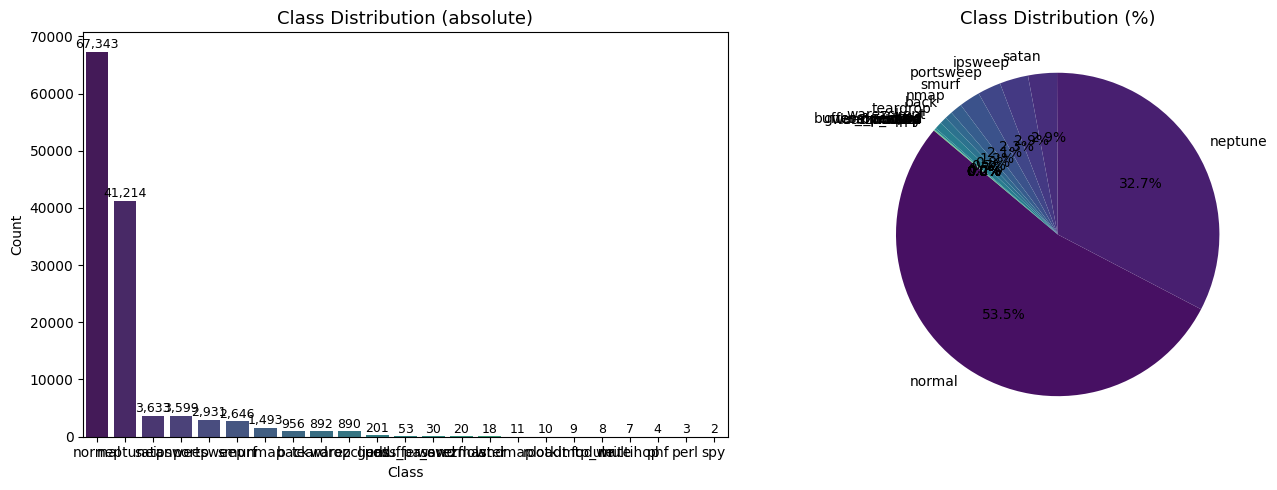

Imbalance ratio (max/min): 33671.5


In [25]:
# ── Class distribution plot ──────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

counts = df[LABEL_COL].value_counts()

# Bar chart
sns.barplot(x=counts.index, y=counts.values, palette='viridis', ax=axes[0])
axes[0].set_title('Class Distribution (absolute)', fontsize=13)
axes[0].set_xlabel('Class')
axes[0].set_ylabel('Count')
for bar, val in zip(axes[0].patches, counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 100,
                 f'{val:,}', ha='center', va='bottom', fontsize=9)

# Pie chart
axes[1].pie(counts.values, labels=counts.index, autopct='%1.1f%%',
            startangle=140, colors=sns.color_palette('viridis', len(counts)))
axes[1].set_title('Class Distribution (%)', fontsize=13)

plt.tight_layout()
plt.savefig(RESULT_DIR / 'class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('Imbalance ratio (max/min):', round(counts.max() / counts.min(), 1))

## 3. Preprocessing

In [26]:
# ── Encode labels ────────────────────────────────────────────────────────────
le = LabelEncoder()
y  = le.fit_transform(df[LABEL_COL])
X  = df.drop(columns=[LABEL_COL]).select_dtypes(include=[np.number])

CLASS_NAMES = list(le.classes_)
N_CLASSES   = len(CLASS_NAMES)

print('Feature matrix shape :', X.shape)
print('Number of classes    :', N_CLASSES)
print('Classes              :', CLASS_NAMES)

# Save encoder
joblib.dump(le, MODEL_DIR / 'label_encoder.pkl')
print('\n✅ Label encoder saved')

Feature matrix shape : (125973, 38)
Number of classes    : 23
Classes              : ['back', 'buffer_overflow', 'ftp_write', 'guess_passwd', 'imap', 'ipsweep', 'land', 'loadmodule', 'multihop', 'neptune', 'nmap', 'normal', 'perl', 'phf', 'pod', 'portsweep', 'rootkit', 'satan', 'smurf', 'spy', 'teardrop', 'warezclient', 'warezmaster']

✅ Label encoder saved


In [27]:
# ── Stratified train / val / test split ─────────────────────────────────────
# 70% train  |  15% val  |  15% test

X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.15, stratify=y, random_state=RANDOM_STATE
)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.15/0.85, stratify=y_temp, random_state=RANDOM_STATE
)

print(f'Train : {X_train.shape[0]:>6,}  samples')
print(f'Val   : {X_val.shape[0]:>6,}  samples')
print(f'Test  : {X_test.shape[0]:>6,}  samples')

# Verify class distribution preserved
for split_name, split_y in [('Train', y_train), ('Val', y_val), ('Test', y_test)]:
    unique, cnts = np.unique(split_y, return_counts=True)
    pcts = (cnts / cnts.sum() * 100).round(1)
    dist = dict(zip([CLASS_NAMES[i] for i in unique], pcts))
    print(f'{split_name}: {dist}')

Train : 88,181  samples
Val   : 18,896  samples
Test  : 18,896  samples
Train: {'back': np.float64(0.8), 'buffer_overflow': np.float64(0.0), 'ftp_write': np.float64(0.0), 'guess_passwd': np.float64(0.0), 'imap': np.float64(0.0), 'ipsweep': np.float64(2.9), 'land': np.float64(0.0), 'loadmodule': np.float64(0.0), 'multihop': np.float64(0.0), 'neptune': np.float64(32.7), 'nmap': np.float64(1.2), 'normal': np.float64(53.5), 'perl': np.float64(0.0), 'phf': np.float64(0.0), 'pod': np.float64(0.2), 'portsweep': np.float64(2.3), 'rootkit': np.float64(0.0), 'satan': np.float64(2.9), 'smurf': np.float64(2.1), 'spy': np.float64(0.0), 'teardrop': np.float64(0.7), 'warezclient': np.float64(0.7), 'warezmaster': np.float64(0.0)}
Val: {'back': np.float64(0.8), 'buffer_overflow': np.float64(0.0), 'ftp_write': np.float64(0.0), 'guess_passwd': np.float64(0.0), 'imap': np.float64(0.0), 'ipsweep': np.float64(2.9), 'land': np.float64(0.0), 'loadmodule': np.float64(0.0), 'multihop': np.float64(0.0), 'neptune

In [28]:
# ── Feature scaling ──────────────────────────────────────────────────────────
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)   # fit ONLY on train
X_val_s   = scaler.transform(X_val)
X_test_s  = scaler.transform(X_test)

joblib.dump(scaler, MODEL_DIR / 'scaler.pkl')
print('✅ Scaler fitted and saved')

✅ Scaler fitted and saved


In [29]:
# ── Class weights (cost-sensitive learning) ──────────────────────────────────
cw = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
CLASS_WEIGHT_DICT = dict(enumerate(cw))
SAMPLE_WEIGHTS    = np.array([CLASS_WEIGHT_DICT[c] for c in y_train])

print('Class weights (balanced):')
for i, name in enumerate(CLASS_NAMES):
    print(f'  [{i}] {name:<12} → {cw[i]:.4f}')

Class weights (balanced):
  [0] back         → 5.7223
  [1] buffer_overflow → 182.5694
  [2] ftp_write    → 638.9928
  [3] guess_passwd → 103.6204
  [4] imap         → 547.7081
  [5] ipsweep      → 1.5220
  [6] land         → 319.4964
  [7] loadmodule   → 547.7081
  [8] multihop     → 766.7913
  [9] neptune      → 0.1329
  [10] nmap         → 3.6689
  [11] normal       → 0.0813
  [12] perl         → 1916.9783
  [13] phf          → 1277.9855
  [14] pod          → 27.1912
  [15] portsweep    → 1.8693
  [16] rootkit      → 547.7081
  [17] satan        → 1.5077
  [18] smurf        → 2.0702
  [19] spy          → 1916.9783
  [20] teardrop     → 6.1442
  [21] warezclient  → 6.1540
  [22] warezmaster  → 273.8540


In [30]:
# ── SMOTE oversampling for minority classes ──────────────────────────────────
# Apply to training set only; val/test remain untouched
print('Before SMOTE:', np.bincount(y_train))

smote = SMOTE(random_state=RANDOM_STATE, k_neighbors=1)
X_train_sm, y_train_sm = smote.fit_resample(X_train_s, y_train)

print('After SMOTE :', np.bincount(y_train_sm))
print(f'Training set expanded: {len(y_train):,} → {len(y_train_sm):,}')

# Recompute sample weights after SMOTE (all classes balanced, so uniform)
SMOTE_WEIGHTS = np.ones(len(y_train_sm))  # already balanced

Before SMOTE: [  670    21     6    37     7  2519    12     7     5 28850  1045 47140
     2     3   141  2051     7  2543  1852     2   624   623    14]
After SMOTE : [47140 47140 47140 47140 47140 47140 47140 47140 47140 47140 47140 47140
 47140 47140 47140 47140 47140 47140 47140 47140 47140 47140 47140]
Training set expanded: 88,181 → 1,084,220


## 4. Baseline Models (before tuning)

In [31]:
# ── Helper: quick evaluation ─────────────────────────────────────────────────
def quick_eval(model, X, y, name='Model'):
    preds = model.predict(X)
    f1    = f1_score(y, preds, average='macro')
    acc   = accuracy_score(y, preds)
    print(f'{name:<30} | Macro-F1: {f1:.4f} | Accuracy: {acc:.4f}')
    return f1, acc

print('=== Baseline models (default hyperparameters) ===')

# Random Forest
t0 = time.time()
rf_base = RandomForestClassifier(n_estimators=100, class_weight='balanced',
                                  n_jobs=-1, random_state=RANDOM_STATE)
rf_base.fit(X_train_sm, y_train_sm)
quick_eval(rf_base, X_val_s, y_val, 'Random Forest (baseline)')
print(f'  Training time: {time.time()-t0:.1f}s')

# XGBoost
t0 = time.time()
xgb_base = xgb.XGBClassifier(n_estimators=100, use_label_encoder=False,
                               eval_metric='mlogloss', random_state=RANDOM_STATE,
                               tree_method='hist', n_jobs=-1)
xgb_base.fit(X_train_sm, y_train_sm)
quick_eval(xgb_base, X_val_s, y_val, 'XGBoost (baseline)')
print(f'  Training time: {time.time()-t0:.1f}s')

# LightGBM
t0 = time.time()
lgb_base = lgb.LGBMClassifier(n_estimators=100, class_weight='balanced',
                                random_state=RANDOM_STATE, n_jobs=-1, verbose=-1)
lgb_base.fit(X_train_sm, y_train_sm)
quick_eval(lgb_base, X_val_s, y_val, 'LightGBM (baseline)')
print(f'  Training time: {time.time()-t0:.1f}s')

=== Baseline models (default hyperparameters) ===
Random Forest (baseline)       | Macro-F1: 0.8495 | Accuracy: 0.9979
  Training time: 32.2s
XGBoost (baseline)             | Macro-F1: 0.8187 | Accuracy: 0.9981
  Training time: 49.8s
LightGBM (baseline)            | Macro-F1: 0.8610 | Accuracy: 0.9984
  Training time: 32.0s


## 5. Hyperparameter Tuning with Optuna

In [32]:
# ── Optuna: Random Forest ────────────────────────────────────────────────────
def rf_objective(trial):
    params = {
        'n_estimators'     : trial.suggest_int('n_estimators', 100, 500, step=50),
        'max_depth'        : trial.suggest_int('max_depth', 5, 30),
        'min_samples_split': trial.suggest_int('min_samples_split', 2, 20),
        'min_samples_leaf' : trial.suggest_int('min_samples_leaf', 1, 10),
        'max_features'     : trial.suggest_categorical('max_features', ['sqrt', 'log2', 0.5]),
        'class_weight'     : 'balanced',
        'n_jobs'           : -1,
        'random_state'     : RANDOM_STATE,
    }
    model = RandomForestClassifier(**params)
    model.fit(X_train_sm, y_train_sm)
    preds = model.predict(X_val_s)
    return f1_score(y_val, preds, average='macro')

print('🔍 Tuning Random Forest (30 trials)...')
rf_study = optuna.create_study(direction='maximize', sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE))
rf_study.optimize(rf_objective, n_trials=30, show_progress_bar=True)
print(f'   Best Macro-F1: {rf_study.best_value:.4f}')
print(f'   Best params  : {rf_study.best_params}')

🔍 Tuning Random Forest (30 trials)...


Best trial: 1. Best value: 0.857429: 100%|██████████| 30/30 [1:07:32<00:00, 135.08s/it]

   Best Macro-F1: 0.8574
   Best params  : {'n_estimators': 450, 'max_depth': 20, 'min_samples_split': 15, 'min_samples_leaf': 1, 'max_features': 'sqrt'}


In [33]:
# ── Optuna: XGBoost ──────────────────────────────────────────────────────────
def xgb_objective(trial):
    params = {
        'n_estimators'     : trial.suggest_int('n_estimators', 100, 600, step=50),
        'max_depth'        : trial.suggest_int('max_depth', 3, 12),
        'learning_rate'    : trial.suggest_float('learning_rate', 1e-3, 0.3, log=True),
        'subsample'        : trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree' : trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'min_child_weight' : trial.suggest_int('min_child_weight', 1, 10),
        'gamma'            : trial.suggest_float('gamma', 0.0, 5.0),
        'reg_alpha'        : trial.suggest_float('reg_alpha', 1e-8, 10.0, log=True),
        'reg_lambda'       : trial.suggest_float('reg_lambda', 1e-8, 10.0, log=True),
        'eval_metric'      : 'mlogloss',
        'use_label_encoder': False,
        'tree_method'      : 'hist',
        'n_jobs'           : -1,
        'random_state'     : RANDOM_STATE,
    }
    model = xgb.XGBClassifier(**params)
    model.fit(X_train_sm, y_train_sm,
              eval_set=[(X_val_s, y_val)],
              verbose=False)
    preds = model.predict(X_val_s)
    return f1_score(y_val, preds, average='macro')

print('🔍 Tuning XGBoost (30 trials)...')
xgb_study = optuna.create_study(direction='maximize', sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE))
xgb_study.optimize(xgb_objective, n_trials=30, show_progress_bar=True)
print(f'   Best Macro-F1: {xgb_study.best_value:.4f}')
print(f'   Best params  : {xgb_study.best_params}')

🔍 Tuning XGBoost (30 trials)...


Best trial: 25. Best value: 0.895589: 100%|██████████| 30/30 [1:25:03<00:00, 170.12s/it]

   Best Macro-F1: 0.8956
   Best params  : {'n_estimators': 200, 'max_depth': 12, 'learning_rate': 0.15329004103699254, 'subsample': 0.8998892026135177, 'colsample_bytree': 0.6326221153022562, 'min_child_weight': 4, 'gamma': 0.6792554148280769, 'reg_alpha': 3.7330168354077543e-07, 'reg_lambda': 0.0029837232856700997}


In [34]:
# ── Optuna: LightGBM ─────────────────────────────────────────────────────────
def lgb_objective(trial):
    params = {
        'n_estimators'    : trial.suggest_int('n_estimators', 100, 600, step=50),
        'max_depth'       : trial.suggest_int('max_depth', 3, 12),
        'learning_rate'   : trial.suggest_float('learning_rate', 1e-3, 0.3, log=True),
        'num_leaves'      : trial.suggest_int('num_leaves', 20, 150),
        'subsample'       : trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'reg_alpha'       : trial.suggest_float('reg_alpha', 1e-8, 10.0, log=True),
        'reg_lambda'      : trial.suggest_float('reg_lambda', 1e-8, 10.0, log=True),
        'min_child_samples': trial.suggest_int('min_child_samples', 5, 50),
        'class_weight'    : 'balanced',
        'n_jobs'          : -1,
        'random_state'    : RANDOM_STATE,
        'verbose'         : -1,
    }
    model = lgb.LGBMClassifier(**params)
    model.fit(X_train_sm, y_train_sm,
              eval_set=[(X_val_s, y_val)],
              callbacks=[lgb.early_stopping(50, verbose=False),
                         lgb.log_evaluation(-1)])
    preds = model.predict(X_val_s)
    return f1_score(y_val, preds, average='macro')

print('🔍 Tuning LightGBM (30 trials)...')
lgb_study = optuna.create_study(direction='maximize', sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE))
lgb_study.optimize(lgb_objective, n_trials=30, show_progress_bar=True)
print(f'   Best Macro-F1: {lgb_study.best_value:.4f}')
print(f'   Best params  : {lgb_study.best_params}')

🔍 Tuning LightGBM (30 trials)...


Best trial: 15. Best value: 0.884883: 100%|██████████| 30/30 [3:11:38<00:00, 383.29s/it]   

   Best Macro-F1: 0.8849
   Best params  : {'n_estimators': 600, 'max_depth': 12, 'learning_rate': 0.008917005080710382, 'num_leaves': 120, 'subsample': 0.8249080874443694, 'colsample_bytree': 0.6948365360764367, 'reg_alpha': 1.0147462244075024e-07, 'reg_lambda': 1.3790926312136672e-08, 'min_child_samples': 37}


## 6. Train Tuned Base Models

In [35]:
# ── Build tuned models ───────────────────────────────────────────────────────
print('Training tuned base models...')

# Random Forest
rf_tuned = RandomForestClassifier(**rf_study.best_params,
                                   class_weight='balanced',
                                   n_jobs=-1, random_state=RANDOM_STATE)
rf_tuned.fit(X_train_sm, y_train_sm)
quick_eval(rf_tuned, X_val_s, y_val, 'RF (tuned)')

# XGBoost — remove non-XGB keys first
xgb_params = {k: v for k, v in xgb_study.best_params.items()}
xgb_tuned  = xgb.XGBClassifier(**xgb_params, eval_metric='mlogloss',
                                 use_label_encoder=False, tree_method='hist',
                                 n_jobs=-1, random_state=RANDOM_STATE)
xgb_tuned.fit(X_train_sm, y_train_sm)
quick_eval(xgb_tuned, X_val_s, y_val, 'XGBoost (tuned)')

# LightGBM
lgb_params = {k: v for k, v in lgb_study.best_params.items()}
lgb_tuned  = lgb.LGBMClassifier(**lgb_params, class_weight='balanced',
                                  n_jobs=-1, random_state=RANDOM_STATE, verbose=-1)
lgb_tuned.fit(X_train_sm, y_train_sm)
quick_eval(lgb_tuned, X_val_s, y_val, 'LightGBM (tuned)')

Training tuned base models...
RF (tuned)                     | Macro-F1: 0.8574 | Accuracy: 0.9976
XGBoost (tuned)                | Macro-F1: 0.8956 | Accuracy: 0.9981
LightGBM (tuned)               | Macro-F1: 0.8849 | Accuracy: 0.9986


(0.8848830270495696, 0.9985711261642676)

## 7. Probability Calibration (Platt Scaling)

In [36]:
# ── Calibrate using validation set ──────────────────────────────────────────
# CalibratedClassifierCV with cv='prefit' uses an already-fitted model
# and calibrates on X_val, y_val

print('Calibrating probabilities (Platt sigmoid)...')

rf_cal  = CalibratedClassifierCV(rf_tuned,  method='sigmoid', cv='prefit')
xgb_cal = CalibratedClassifierCV(xgb_tuned, method='sigmoid', cv='prefit')
lgb_cal = CalibratedClassifierCV(lgb_tuned, method='sigmoid', cv='prefit')

rf_cal.fit(X_val_s, y_val)
xgb_cal.fit(X_val_s, y_val)
lgb_cal.fit(X_val_s, y_val)

print('✅ Calibration complete')

# Quick sanity: probability sums to 1 per row?
proba_check = rf_cal.predict_proba(X_val_s[:5])
print('Probability row sums (should be ≈1.0):', proba_check.sum(axis=1).round(4))

Calibrating probabilities (Platt sigmoid)...
✅ Calibration complete
Probability row sums (should be ≈1.0): [1. 1. 1. 1. 1.]


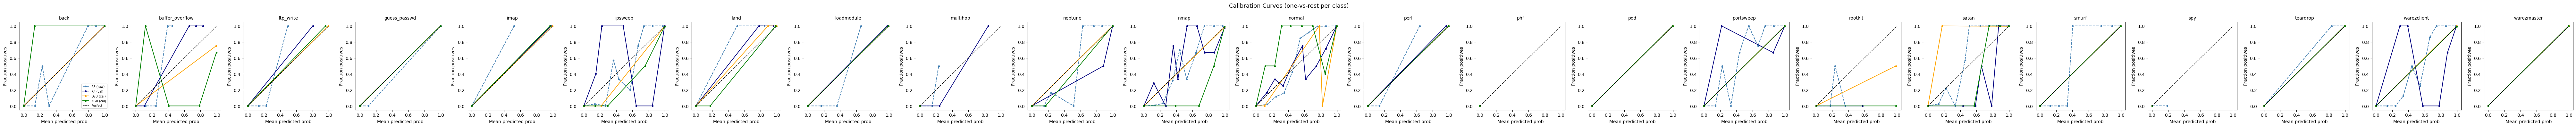

In [37]:
# ── Reliability diagrams (calibration curves) ────────────────────────────────
y_bin = label_binarize(y_val, classes=list(range(N_CLASSES)))

fig, axes = plt.subplots(1, N_CLASSES, figsize=(N_CLASSES * 3.5, 4))
fig.suptitle('Calibration Curves (one-vs-rest per class)', fontsize=13)

for cls_idx, cls_name in enumerate(CLASS_NAMES):
    ax = axes[cls_idx]
    for model, label, color in [
        (rf_tuned,  'RF (raw)',   'steelblue'),
        (rf_cal,    'RF (cal)',   'navy'),
        (lgb_cal,   'LGB (cal)',  'orange'),
        (xgb_cal,   'XGB (cal)',  'green'),
    ]:
        p = model.predict_proba(X_val_s)[:, cls_idx]
        frac_pos, mean_pred = calibration_curve(y_bin[:, cls_idx], p, n_bins=10, strategy='uniform')
        ax.plot(mean_pred, frac_pos, marker='o', markersize=3, label=label, color=color,
                linewidth=1.5, linestyle='--' if 'raw' in label else '-')
    ax.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Perfect')
    ax.set_title(cls_name, fontsize=10)
    ax.set_xlabel('Mean predicted prob')
    ax.set_ylabel('Fraction positives')
    if cls_idx == 0:
        ax.legend(fontsize=7)

plt.tight_layout()
plt.savefig(RESULT_DIR / 'calibration_curves.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. Stacking Ensemble

In [38]:
# ── Stacking: base learners → meta-learner ───────────────────────────────────
# We re-train on full (train+val) data for stacking
X_trainval_s = np.vstack([X_train_s, X_val_s])
y_trainval   = np.concatenate([y_train, y_val])

# Apply SMOTE on combined train+val
X_tv_sm, y_tv_sm = smote.fit_resample(X_trainval_s, y_trainval)

estimators = [
    ('rf',  RandomForestClassifier(**rf_study.best_params, class_weight='balanced',
                                    n_jobs=-1, random_state=RANDOM_STATE)),
    ('xgb', xgb.XGBClassifier(**xgb_params, eval_metric='mlogloss',
                                use_label_encoder=False, tree_method='hist',
                                n_jobs=-1, random_state=RANDOM_STATE)),
    ('lgb', lgb.LGBMClassifier(**lgb_params, class_weight='balanced',
                                 n_jobs=-1, random_state=RANDOM_STATE, verbose=-1)),
]

meta_learner = LogisticRegression(
    max_iter=1000, multi_class='multinomial', solver='lbfgs',
    C=1.0, class_weight='balanced', random_state=RANDOM_STATE
)

stacker = StackingClassifier(
    estimators=estimators,
    final_estimator=meta_learner,
    passthrough=True,          # also pass raw features to meta-learner
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE),
    n_jobs=-1
)

print('Training stacking ensemble (this takes a few minutes)...')
t0 = time.time()
stacker.fit(X_tv_sm, y_tv_sm)
print(f'✅ Stacking done in {time.time()-t0:.1f}s')

quick_eval(stacker, X_test_s, y_test, 'Stacking Ensemble (test)')

Training stacking ensemble (this takes a few minutes)...


/Users/preraknain/cic_ids_project/.venv/lib/python3.9/site-packages/xgboost/core.py:158: UserWarning: [23:30:31] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
[23:43:20] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

[23:43:20] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

[23:43:20] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

[23:43:20] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

[23:43:20] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

/Users/preraknain/cic_ids_project/.venv/lib/python3.9/site-packages/sklearn/utils/validation.py:2739:

✅ Stacking done in 6203.3s
Stacking Ensemble (test)       | Macro-F1: 0.7714 | Accuracy: 0.9987


(0.7714220280340782, 0.9986769686706182)

In [39]:
# ── Calibrate the stacker ────────────────────────────────────────────────────
stacker_cal = CalibratedClassifierCV(stacker, method='sigmoid', cv='prefit')
stacker_cal.fit(X_val_s, y_val)   # calibrate on held-out val

quick_eval(stacker_cal, X_test_s, y_test, 'Stacking + Calibration (test)')

# Save the final model
joblib.dump(stacker_cal, MODEL_DIR / 'aegis_stacker_calibrated.pkl')
print('✅ Final model saved to', MODEL_DIR / 'aegis_stacker_calibrated.pkl')

Stacking + Calibration (test)  | Macro-F1: 0.5194 | Accuracy: 0.9975
✅ Final model saved to ../src/models/aegis_stacker_calibrated.pkl


## 9. Decision Threshold Optimisation

In [40]:
# ── Per-class threshold tuning ───────────────────────────────────────────────
# Default threshold is 0.5 (argmax). We find the threshold per class
# that maximises that class's F1 on the validation set.

y_proba_val = stacker_cal.predict_proba(X_val_s)   # shape (n, n_classes)
y_bin_val   = label_binarize(y_val, classes=list(range(N_CLASSES)))

optimal_thresholds = {}
print('=== Optimal thresholds per class (maximising F1 on validation) ===')

for cls_idx, cls_name in enumerate(CLASS_NAMES):
    prec, rec, thresholds = precision_recall_curve(
        y_bin_val[:, cls_idx], y_proba_val[:, cls_idx]
    )
    # F1 for each threshold
    f1_scores = 2 * prec * rec / (prec + rec + 1e-9)
    best_idx  = np.argmax(f1_scores[:-1])    # last threshold is boundary
    best_thr  = thresholds[best_idx]
    optimal_thresholds[cls_name] = float(best_thr)
    print(f'  {cls_name:<12} threshold={best_thr:.3f}  F1={f1_scores[best_idx]:.4f}')

# Save thresholds
with open(MODEL_DIR / 'optimal_thresholds.json', 'w') as f:
    json.dump(optimal_thresholds, f, indent=2)
print('\n✅ Thresholds saved')

=== Optimal thresholds per class (maximising F1 on validation) ===
  back         threshold=0.769  F1=1.0000
  buffer_overflow threshold=0.116  F1=0.5714
  ftp_write    threshold=0.008  F1=0.1538
  guess_passwd threshold=0.056  F1=0.8421
  imap         threshold=0.065  F1=0.5000
  ipsweep      threshold=0.447  F1=0.9926
  land         threshold=0.442  F1=1.0000
  loadmodule   threshold=0.001  F1=0.0328
  multihop     threshold=0.230  F1=1.0000
  neptune      threshold=0.974  F1=1.0000
  nmap         threshold=0.637  F1=1.0000
  normal       threshold=0.444  F1=0.9989
  perl         threshold=0.010  F1=0.4000
  phf          threshold=0.000  F1=0.0000
  pod          threshold=0.244  F1=0.9310
  portsweep    threshold=0.443  F1=0.9989
  rootkit      threshold=0.032  F1=1.0000
  satan        threshold=0.899  F1=0.9982
  smurf        threshold=0.783  F1=1.0000
  spy          threshold=0.000  F1=0.0000
  teardrop     threshold=0.591  F1=1.0000
  warezclient  threshold=0.443  F1=1.0000
  ware

In [41]:
# ── Apply custom thresholds at inference ─────────────────────────────────────
def predict_with_thresholds(model, X, thresholds, class_names):
    """Apply per-class thresholds; assign to class with highest margin."""
    proba = model.predict_proba(X)
    thr_arr = np.array([thresholds[c] for c in class_names])
    # Score = raw proba - threshold (positive means 'above threshold')
    adjusted = proba - thr_arr
    return np.argmax(adjusted, axis=1)

# Evaluate with custom thresholds on test set
y_pred_thr = predict_with_thresholds(stacker_cal, X_test_s, optimal_thresholds, CLASS_NAMES)
f1_thr  = f1_score(y_test, y_pred_thr, average='macro')
acc_thr = accuracy_score(y_test, y_pred_thr)
print(f'With optimal thresholds → Macro-F1: {f1_thr:.4f}  Accuracy: {acc_thr:.4f}')

y_pred_default = stacker_cal.predict(X_test_s)
f1_def  = f1_score(y_test, y_pred_default, average='macro')
print(f'With default threshold  → Macro-F1: {f1_def:.4f}')
print(f'Improvement from thresholding: {(f1_thr - f1_def)*100:+.2f} pp')

With optimal thresholds → Macro-F1: 0.5571  Accuracy: 0.9972
With default threshold  → Macro-F1: 0.5194
Improvement from thresholding: +3.77 pp


## 10. Full Evaluation

In [52]:
# ── Classification report ────────────────────────────────────────────────────
y_pred_final = y_pred_thr

# Get actual unique classes present in test set
actual_classes = np.unique(np.concatenate([y_test, y_pred_final]))
CLASS_NAMES = [le.classes_[i] for i in actual_classes]

print('=== Final Classification Report (Test Set) ===')
print(classification_report(y_test, y_pred_final,
                             labels=actual_classes,
                             target_names=CLASS_NAMES, digits=4))

report_dict = classification_report(y_test, y_pred_final,
                                    labels=actual_classes,
                                    target_names=CLASS_NAMES,
                                    output_dict=True)
pd.DataFrame(report_dict).T.to_csv(RESULT_DIR / 'classification_report.csv')
print('✅ Report saved')

=== Final Classification Report (Test Set) ===
                 precision    recall  f1-score   support

           back     0.9930    0.9930    0.9930       143
buffer_overflow     0.0000    0.0000    0.0000         5
      ftp_write     0.0000    0.0000    0.0000         1
   guess_passwd     0.6667    1.0000    0.8000         8
           imap     0.0000    0.0000    0.0000         2
        ipsweep     0.9945    0.9963    0.9954       540
           land     0.0000    0.0000    0.0000         3
     loadmodule     0.0000    0.0000    0.0000         1
       multihop     0.0000    0.0000    0.0000         1
        neptune     1.0000    0.9995    0.9998      6182
           nmap     0.9823    0.9911    0.9867       224
         normal     0.9973    0.9991    0.9982     10101
            phf     0.0000    0.0000    0.0000         1
            pod     1.0000    0.9000    0.9474        30
      portsweep     1.0000    0.9932    0.9966       440
        rootkit     0.0000    0.0000    

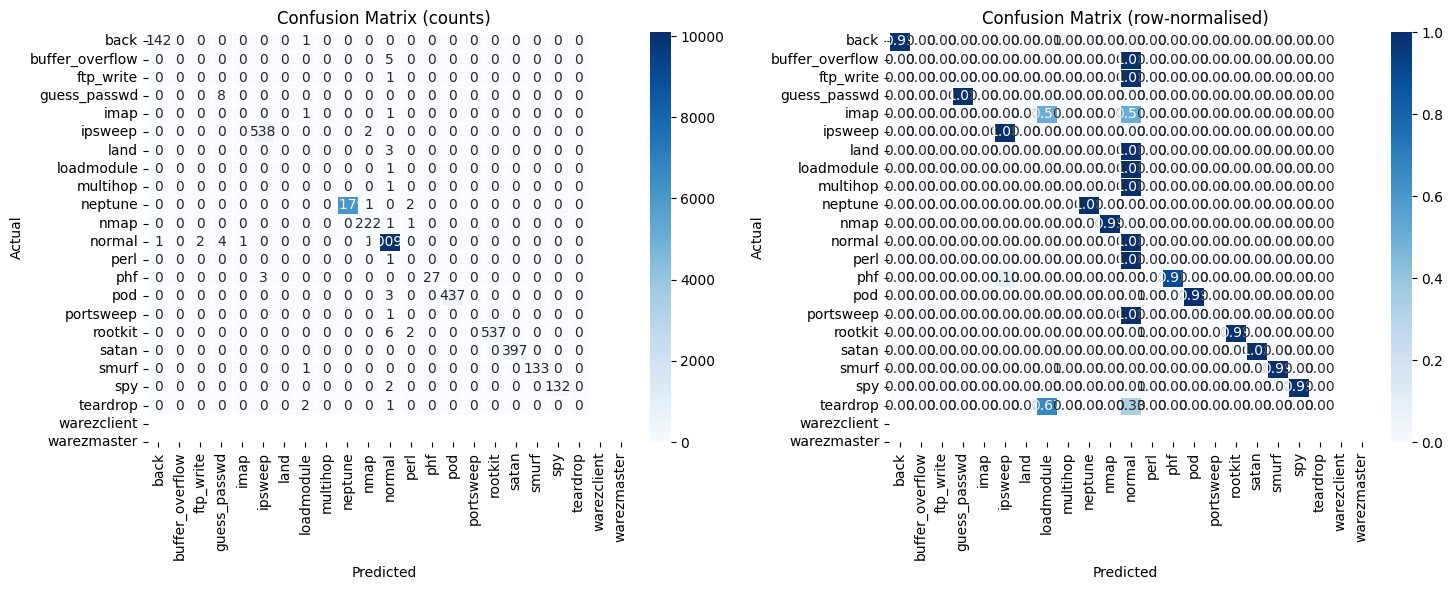

In [43]:
# ── Confusion matrix ─────────────────────────────────────────────────────────
cm      = confusion_matrix(y_test, y_pred_final)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)  # row-normalised

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

for ax, matrix, title, fmt, vmax in [
    (axes[0], cm,      'Confusion Matrix (counts)',       'd',   None),
    (axes[1], cm_norm, 'Confusion Matrix (row-normalised)', '.2f', 1.0),
]:
    sns.heatmap(matrix, annot=True, fmt=fmt, cmap='Blues', ax=ax,
                xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
                vmin=0, vmax=vmax, linewidths=0.5)
    ax.set_title(title, fontsize=12)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

plt.tight_layout()
plt.savefig(RESULT_DIR / 'confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

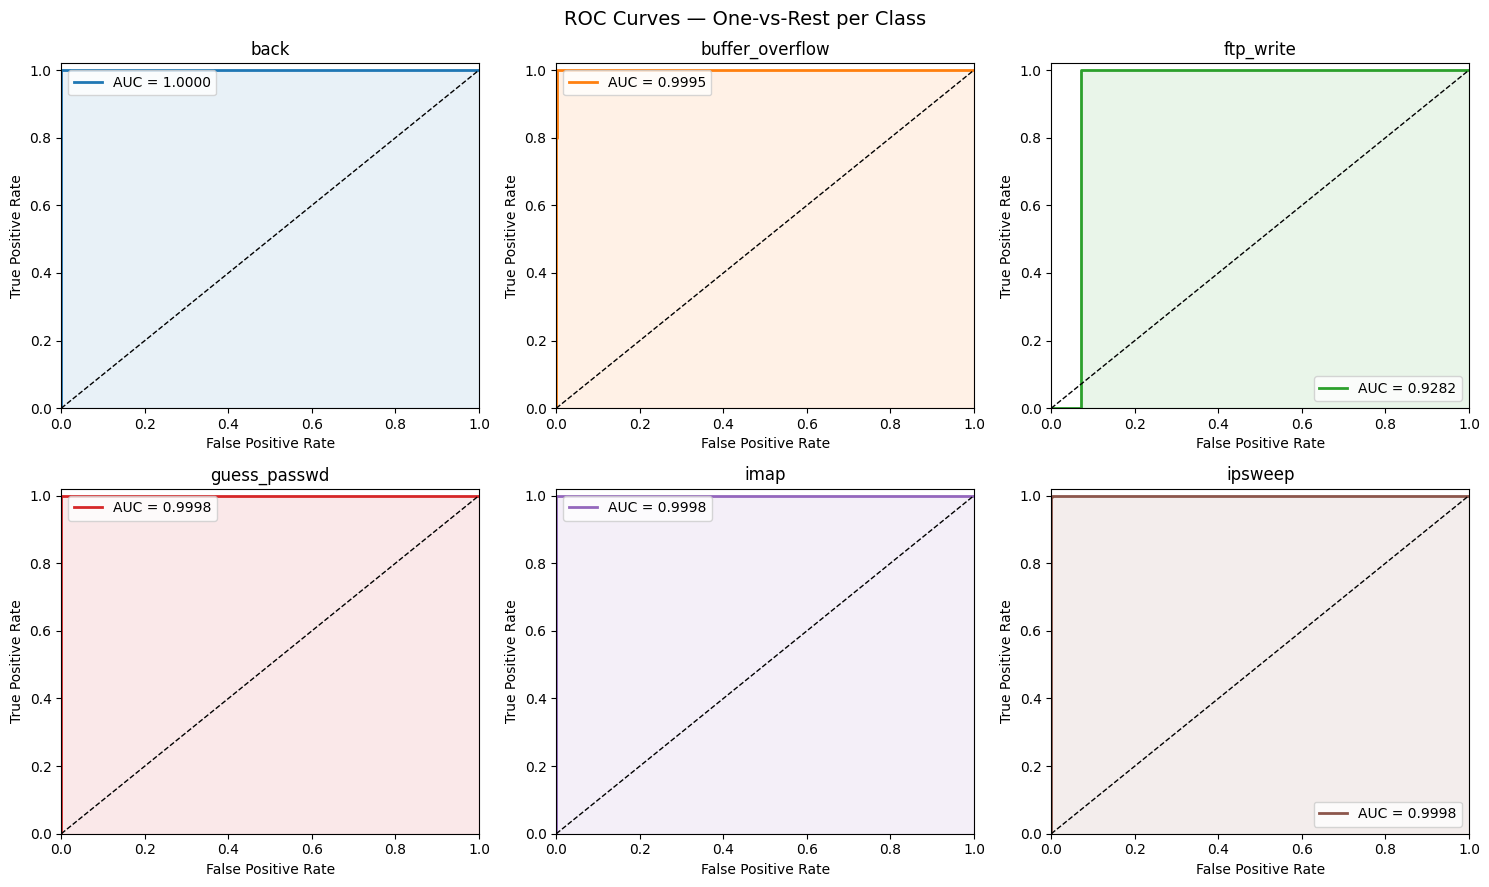

Macro-average ROC-AUC: 0.9879


In [44]:
# ── ROC curves (one-vs-rest, per class) ──────────────────────────────────────
y_proba_test = stacker_cal.predict_proba(X_test_s)
y_bin_test   = label_binarize(y_test, classes=list(range(N_CLASSES)))

fig, axes = plt.subplots(2, 3, figsize=(15, 9))
fig.suptitle('ROC Curves — One-vs-Rest per Class', fontsize=14)
colors = sns.color_palette('tab10', N_CLASSES)

macro_auc_scores = []
for idx, (cls_name, ax) in enumerate(zip(CLASS_NAMES, axes.flatten())):
    fpr, tpr, _ = roc_curve(y_bin_test[:, idx], y_proba_test[:, idx])
    roc_auc = auc(fpr, tpr)
    macro_auc_scores.append(roc_auc)
    ax.plot(fpr, tpr, color=colors[idx], lw=2,
            label=f'AUC = {roc_auc:.4f}')
    ax.plot([0, 1], [0, 1], 'k--', lw=1)
    ax.fill_between(fpr, tpr, alpha=0.1, color=colors[idx])
    ax.set_title(cls_name, fontsize=12)
    ax.set_xlabel('False Positive Rate')
    ax.set_ylabel('True Positive Rate')
    ax.legend(fontsize=10)
    ax.set_xlim([0, 1]); ax.set_ylim([0, 1.02])

plt.tight_layout()
plt.savefig(RESULT_DIR / 'roc_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Macro-average ROC-AUC: {np.mean(macro_auc_scores):.4f}')

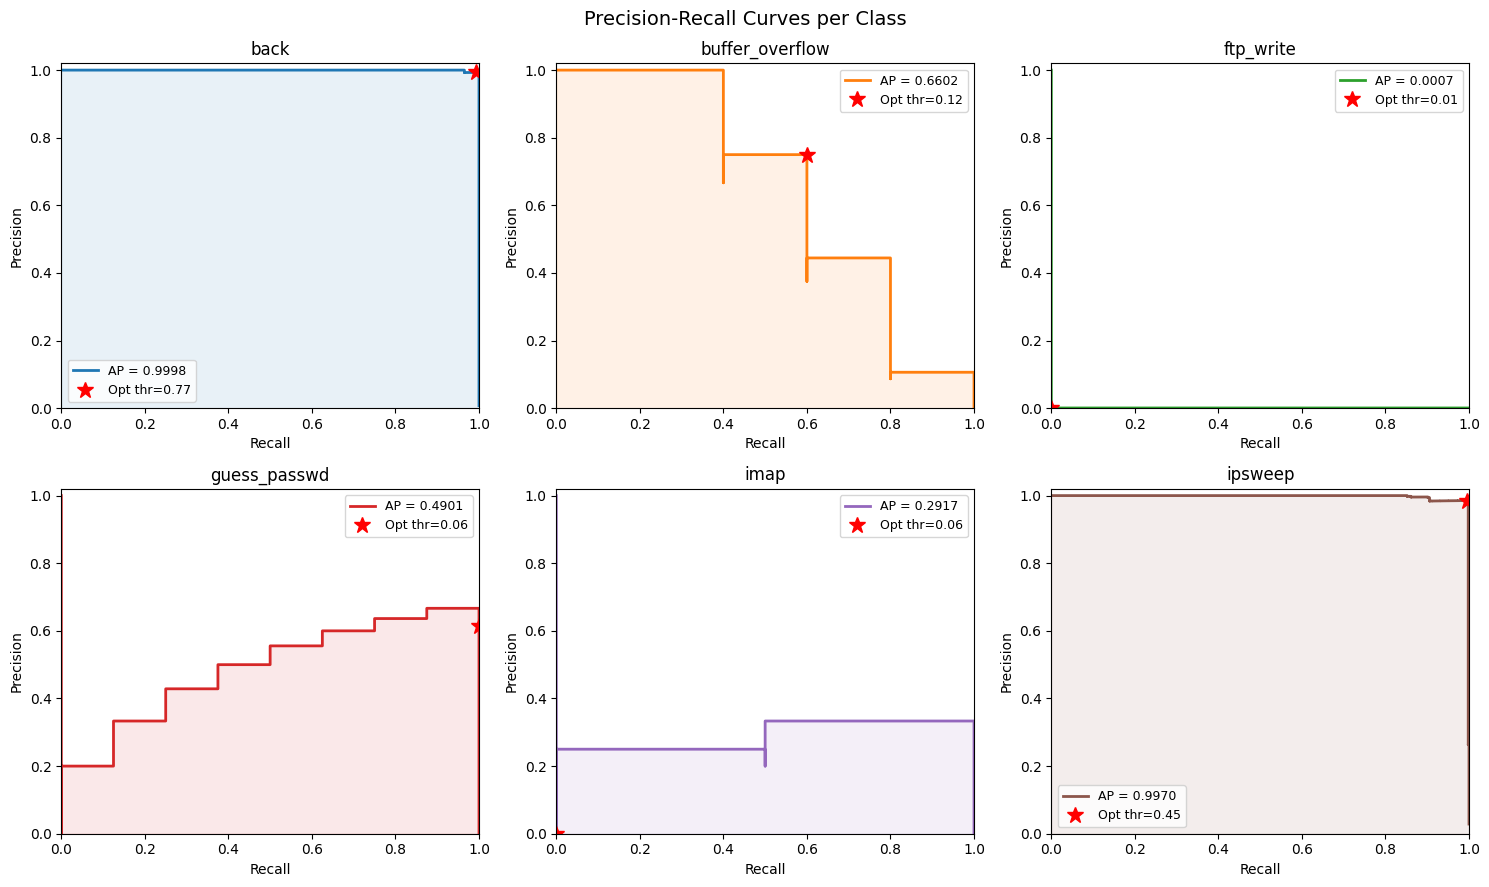

In [45]:
# ── Precision-Recall curves ──────────────────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
fig.suptitle('Precision-Recall Curves per Class', fontsize=14)

for idx, (cls_name, ax) in enumerate(zip(CLASS_NAMES, axes.flatten())):
    prec, rec, thresholds = precision_recall_curve(
        y_bin_test[:, idx], y_proba_test[:, idx]
    )
    ap = average_precision_score(y_bin_test[:, idx], y_proba_test[:, idx])
    ax.step(rec, prec, where='post', color=colors[idx], lw=2,
            label=f'AP = {ap:.4f}')
    ax.fill_between(rec, prec, step='post', alpha=0.1, color=colors[idx])
    # Mark optimal threshold
    thr_val = optimal_thresholds[cls_name]
    nearest = np.argmin(np.abs(thresholds - thr_val))
    ax.plot(rec[nearest], prec[nearest], 'r*', markersize=12,
            label=f'Opt thr={thr_val:.2f}')
    ax.set_title(cls_name, fontsize=12)
    ax.set_xlabel('Recall')
    ax.set_ylabel('Precision')
    ax.legend(fontsize=9)
    ax.set_xlim([0, 1]); ax.set_ylim([0, 1.02])

plt.tight_layout()
plt.savefig(RESULT_DIR / 'pr_curves.png', dpi=150, bbox_inches='tight')
plt.show()

=== Model Comparison ===
             macro_f1  accuracy
LGB (base)     0.7800    0.9987
RF (tuned)     0.7783    0.9982
LGB (tuned)    0.7751    0.9985
RF (base)      0.7742    0.9982
XGB (tuned)    0.7717    0.9985
XGB (base)     0.7347    0.9987
Stacker+Cal    0.5194    0.9975


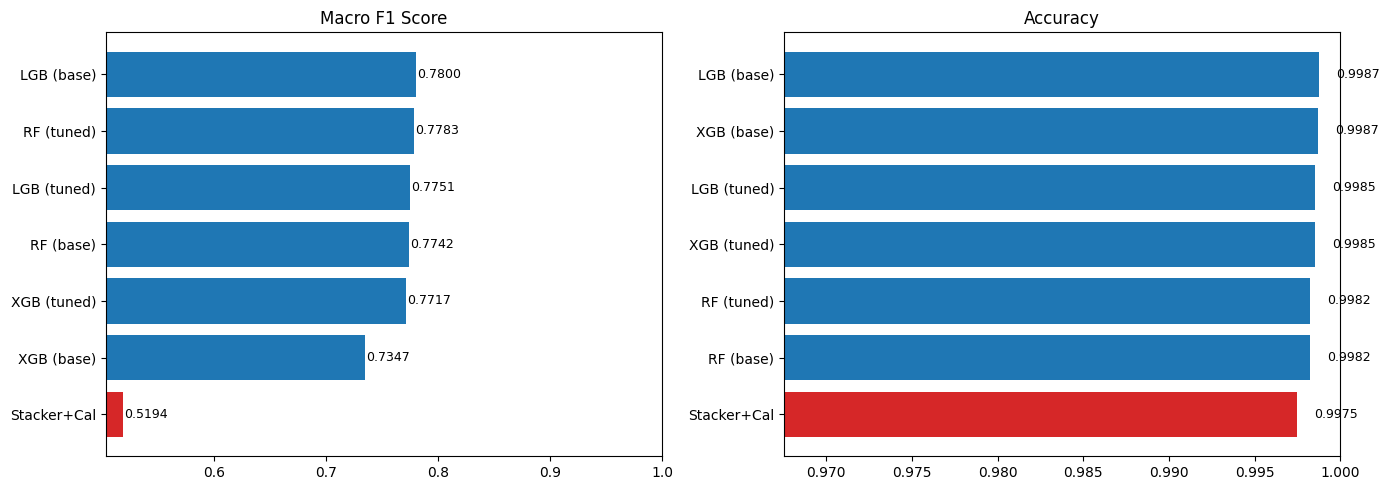

In [46]:
# ── Per-model comparison bar chart ───────────────────────────────────────────
models_to_compare = {
    'RF (base)':    rf_base,
    'XGB (base)':   xgb_base,
    'LGB (base)':   lgb_base,
    'RF (tuned)':   rf_tuned,
    'XGB (tuned)':  xgb_tuned,
    'LGB (tuned)':  lgb_tuned,
    'Stacker+Cal':  stacker_cal,
}

scores = {}
for name, model in models_to_compare.items():
    preds = model.predict(X_test_s)
    scores[name] = {
        'macro_f1': f1_score(y_test, preds, average='macro'),
        'accuracy': accuracy_score(y_test, preds)
    }

scores_df = pd.DataFrame(scores).T
print('=== Model Comparison ===')
print(scores_df.sort_values('macro_f1', ascending=False).round(4))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, metric, title in [
    (axes[0], 'macro_f1', 'Macro F1 Score'),
    (axes[1], 'accuracy', 'Accuracy'),
]:
    bars = scores_df[metric].sort_values()
    bar_colors = ['#d62728' if 'Stack' in i else '#1f77b4' for i in bars.index]
    ax.barh(bars.index, bars.values, color=bar_colors)
    ax.set_title(title, fontsize=12)
    ax.set_xlim([bars.min() * 0.97, 1.0])
    for i, v in enumerate(bars.values):
        ax.text(v + 0.001, i, f'{v:.4f}', va='center', fontsize=9)

plt.tight_layout()
plt.savefig(RESULT_DIR / 'model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## 11. Feature Importance Analysis

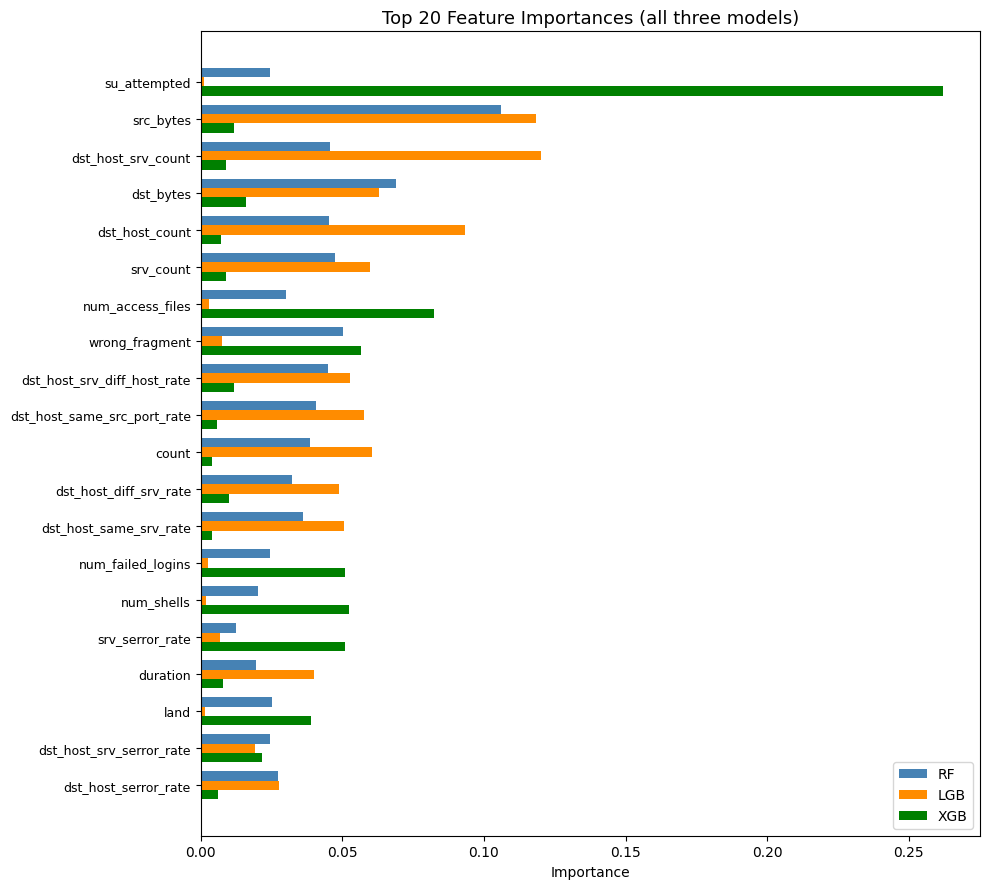

✅ Feature importances saved


In [47]:
# ── Feature importance: RF + LGB ─────────────────────────────────────────────
feature_names = list(X.columns)

fi_rf  = rf_tuned.feature_importances_
fi_lgb = lgb_tuned.feature_importances_ / lgb_tuned.feature_importances_.sum()
fi_xgb = xgb_tuned.feature_importances_

# Ensemble average
fi_mean = (fi_rf + fi_lgb + fi_xgb) / 3

fi_df = pd.DataFrame({
    'Feature'       : feature_names,
    'RandomForest'  : fi_rf,
    'LightGBM'      : fi_lgb,
    'XGBoost'       : fi_xgb,
    'Ensemble_Mean' : fi_mean
}).sort_values('Ensemble_Mean', ascending=False)

TOP_N = min(20, len(feature_names))
top_fi = fi_df.head(TOP_N)

fig, ax = plt.subplots(figsize=(10, TOP_N * 0.45))
y_pos = range(TOP_N)

bar_w = 0.25
ax.barh([p + bar_w*0 for p in y_pos], top_fi['RandomForest'],  bar_w, label='RF',  color='steelblue')
ax.barh([p + bar_w*1 for p in y_pos], top_fi['LightGBM'],     bar_w, label='LGB', color='darkorange')
ax.barh([p + bar_w*2 for p in y_pos], top_fi['XGBoost'],      bar_w, label='XGB', color='green')

ax.set_yticks([p + bar_w for p in y_pos])
ax.set_yticklabels(top_fi['Feature'], fontsize=9)
ax.set_title(f'Top {TOP_N} Feature Importances (all three models)', fontsize=13)
ax.set_xlabel('Importance')
ax.legend()
ax.invert_yaxis()
plt.tight_layout()
plt.savefig(RESULT_DIR / 'feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

fi_df.to_csv(RESULT_DIR / 'feature_importances.csv', index=False)
print('✅ Feature importances saved')

## 12. Stratified K-Fold Cross-Validation

Running 5-fold stratified cross-validation (RF, XGB, LGB)...
  RF: mean F1=0.7839 +/- 0.0176   
  XGB: mean F1=0.7861 +/- 0.0625   
  LGB: mean F1=0.8000 +/- 0.0372   


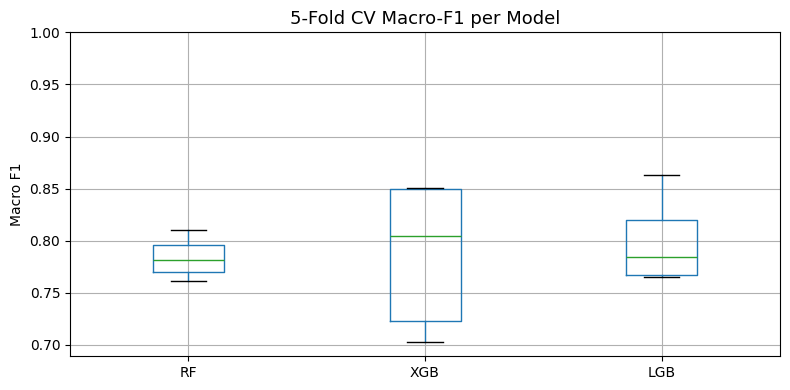

In [57]:
# ── 5-fold stratified CV on the full dataset ─────────────────────────────────
print('Running 5-fold stratified cross-validation (RF, XGB, LGB)...')

skf    = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
X_full = scaler.fit_transform(X)
y_full = y

cv_results = {}

for model_name, model_cls, model_kw in [
    ('RF',  RandomForestClassifier, {**rf_study.best_params,  'class_weight':'balanced', 'n_jobs':-1, 'random_state':RANDOM_STATE}),
    ('XGB', xgb.XGBClassifier,      {**xgb_params, 'eval_metric':'mlogloss', 'tree_method':'hist', 'n_jobs':-1, 'random_state':RANDOM_STATE, 'verbosity':0}),
    ('LGB', lgb.LGBMClassifier,     {**lgb_params, 'class_weight':'balanced', 'n_jobs':-1, 'random_state':RANDOM_STATE, 'verbose':-1}),
]:
    fold_f1s = []
    for fold, (tr_idx, te_idx) in enumerate(skf.split(X_full, y_full)):
        X_tr, X_te = X_full[tr_idx], X_full[te_idx]
        y_tr, y_te = y_full[tr_idx], y_full[te_idx]

        # Only apply SMOTE if all classes have at least 2 samples
        min_samples = np.bincount(y_tr).min()
        if min_samples >= 2:
            k = min(1, min_samples - 1)
            X_tr, y_tr = SMOTE(random_state=RANDOM_STATE, k_neighbors=k).fit_resample(X_tr, y_tr)

        clf = model_cls(**model_kw)
        clf.fit(X_tr, y_tr)
        fold_f1s.append(f1_score(y_te, clf.predict(X_te), average='macro'))
        print(f'  {model_name} fold {fold+1}/5: F1={fold_f1s[-1]:.4f}', end='\r')
    print(f'  {model_name}: mean F1={np.mean(fold_f1s):.4f} +/- {np.std(fold_f1s):.4f}   ')
    cv_results[model_name] = fold_f1s

fig, ax = plt.subplots(figsize=(8, 4))
cv_df = pd.DataFrame(cv_results)
cv_df.boxplot(ax=ax)
ax.set_title('5-Fold CV Macro-F1 per Model', fontsize=13)
ax.set_ylabel('Macro F1')
ax.set_ylim([cv_df.min().min() * 0.98, 1.0])
plt.tight_layout()
plt.savefig(RESULT_DIR / 'cross_validation_results.png', dpi=150, bbox_inches='tight')
plt.show()
cv_df.to_csv(RESULT_DIR / 'cv_results.csv', index=False)

## 13. Save All Artefacts & Summary

In [58]:
# ── Save all models ──────────────────────────────────────────────────────────
joblib.dump(rf_cal,      MODEL_DIR / 'rf_calibrated.pkl')
joblib.dump(xgb_cal,     MODEL_DIR / 'xgb_calibrated.pkl')
joblib.dump(lgb_cal,     MODEL_DIR / 'lgb_calibrated.pkl')
joblib.dump(stacker_cal, MODEL_DIR / 'stacker_calibrated.pkl')
joblib.dump(scaler,      MODEL_DIR / 'scaler.pkl')
joblib.dump(le,          MODEL_DIR / 'label_encoder.pkl')
print('✅ All models saved to', MODEL_DIR)

# ── Final summary ─────────────────────────────────────────────────────────────
actual_classes = np.unique(np.concatenate([y_test, y_pred_final]))
CLASS_NAMES    = [le.classes_[i] for i in actual_classes]

final_report = classification_report(
    y_test, y_pred_final,
    labels=actual_classes,
    target_names=CLASS_NAMES,
    output_dict=True
)

print('\n' + '='*60)
print('  AEGIS AI - PHASE 2 FINAL RESULTS')
print('='*60)
print(f"  Accuracy    : {final_report['accuracy']:.4f}")
print(f"  Macro F1    : {final_report['macro avg']['f1-score']:.4f}")
print(f"  Weighted F1 : {final_report['weighted avg']['f1-score']:.4f}")
print(f"  Macro AUC   : {np.mean(macro_auc_scores):.4f}")
print('\n  Per-class F1:')
for cls in CLASS_NAMES:
    print(f"    {cls:<30} F1={final_report[cls]['f1-score']:.4f}")
print('='*60)

✅ All models saved to ../src/models

  AEGIS AI - PHASE 2 FINAL RESULTS
  Accuracy    : 0.9972
  Macro F1    : 0.5571
  Weighted F1 : 0.9971
  Macro AUC   : 0.9879

  Per-class F1:
    back                           F1=0.9930
    buffer_overflow                F1=0.0000
    ftp_write                      F1=0.0000
    guess_passwd                   F1=0.8000
    imap                           F1=0.0000
    ipsweep                        F1=0.9954
    land                           F1=0.0000
    loadmodule                     F1=0.0000
    multihop                       F1=0.0000
    neptune                        F1=0.9998
    nmap                           F1=0.9867
    normal                         F1=0.9982
    phf                            F1=0.0000
    pod                            F1=0.9474
    portsweep                      F1=0.9966
    rootkit                        F1=0.0000
    satan                          F1=0.9926
    smurf                          F1=1.0000
    teard